# TabNet PEAD — Trading Strategy Backtest

Uses the TabNet classifier predictions to generate buy signals (class 1 or 2) and simulates
an equity curve from 2021–2025.

## Strategy Rules

1. **Entry**: Buy at close on t+1 when predicted class is 1 (Moderate) or 2 (Strong)
2. **Position size**: $1,000 CAD per trade
3. **Exit — hit target**: If the stock reaches >2% gain during the window, exit at 2%
4. **Exit — time stop**: If the stock never reaches 2%, exit at t+10 close

## Metrics
- Per-quarter gain/loss, win rate, Sharpe ratio
- Cumulative equity curve
- Drawdown analysis

In [19]:
from pathlib import Path
import json
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({"figure.dpi": 100, "font.size": 9})

In [20]:
# ── Load results (same path logic as analysis_results.ipynb) ─────────
output_dir = Path("modal_tabnet_outputs")
if not output_dir.exists():
    output_dir = Path("src") / "modeling" / "modal_tabnet_outputs"
DATA_DIR = str(output_dir)

results = pl.read_parquet(f"{DATA_DIR}/results.parquet")
summary = pl.read_parquet(f"{DATA_DIR}/per_fold_summary.parquet")

print(f"Total predictions: {len(results)}")
print(f"Date range: {results['earnings_date'].min()} to {results['earnings_date'].max()}")
print(f"Quarters: {results['quarter'].n_unique()}")

Total predictions: 9937
Date range: 2021-01-07 to 2025-12-19
Quarters: 20


---
## 1. Filter buy signals & compute trade returns

In [21]:
# ── Only trade when predicted class is 1 or 2 ────────────────────────
signals = results.filter(pl.col("target_class_predicted").is_in([1, 2]))
print(f"Buy signals: {len(signals)} / {len(results)} ({len(signals)/len(results)*100:.1f}%)")

# ── Compute trade return per position ────────────────────────────────
# Rule: if actual return > 2%, cap at 2% (hit target, exit early).
#       if actual return <= 2%, use actual return (exit at t+10).
positions = 100  # CAD per trade

signals = signals.with_columns(
    pl.when(pl.col("target_return_actual") > 0.02)
    .then(0.02)
    .otherwise(pl.col("target_return_actual"))
    .alias("trade_return"),
)

# ── Dollar P&L per trade ─────────────────────────────────────────────
signals = signals.with_columns(
    (pl.col("trade_return") * positions).alias("pnl_per_trade"),
)

print(f"\nTrade returns (capped at 2%):")
print(f"  Mean:   {signals['trade_return'].mean():.4f}")
print(f"  Median: {signals['trade_return'].median():.4f}")
print(f"  Std:    {signals['trade_return'].std():.4f}")
print(f"  Min:    {signals['trade_return'].min():.4f}")
print(f"  Max:    {signals['trade_return'].max():.4f}")
print(f"\nWin rate (return > 0): {(signals['trade_return'] > 0).mean():.2%}")

# Sort by earnings date for chronological equity curve
signals = signals.sort("earnings_date")
signals.head(10)

Buy signals: 8221 / 9937 (82.7%)

Trade returns (capped at 2%):
  Mean:   0.0168
  Median: 0.0200
  Std:    0.0071
  Min:    -0.1315
  Max:    0.0200

Win rate (return > 0): 95.72%


quarter,fold_num,symbol,earnings_date,entry_price,target_class_actual,target_class_predicted,prob_class_0,prob_class_1,prob_class_2,target_return_actual,target_return_predicted,trade_return,pnl_per_trade
str,i64,str,date,f64,i64,i64,f32,f32,f32,f64,f64,f64,f64
"""2021_Q1""",1,"""CAG""",2021-01-07,26.017023,0,2,0.244583,0.287258,0.468159,0.017611,0.036741,0.017611,1.761094
"""2021_Q1""",1,"""STZ""",2021-01-07,209.285339,0,1,0.322814,0.348016,0.329169,0.003432,0.031701,0.003432,0.343173
"""2021_Q1""",1,"""DAL""",2021-01-14,38.686096,2,2,0.221567,0.259499,0.518934,0.044772,0.017485,0.02,2.0
"""2021_Q1""",1,"""WFC""",2021-01-15,28.774231,0,2,0.325975,0.31004,0.363985,0.006129,0.025293,0.006129,0.612941
"""2021_Q1""",1,"""JPM""",2021-01-15,120.942741,0,1,0.345595,0.347501,0.306904,0.000942,-0.043854,0.000942,0.094162
"""2021_Q1""",1,"""HAL""",2021-01-19,18.261755,0,2,0.229651,0.258312,0.512037,0.015438,0.084863,0.015438,1.543824
"""2021_Q1""",1,"""NFLX""",2021-01-19,58.633999,0,2,0.263289,0.283241,0.45347,0.00411,0.036349,0.00411,0.411026
"""2021_Q1""",1,"""GS""",2021-01-19,256.587067,0,2,0.311708,0.222862,0.46543,0.007815,-0.011439,0.007815,0.781457
"""2021_Q1""",1,"""STT""",2021-01-19,64.934708,0,2,0.226878,0.277954,0.495168,0.005089,0.074703,0.005089,0.508877


---
## 2. Cumulative Equity Curve

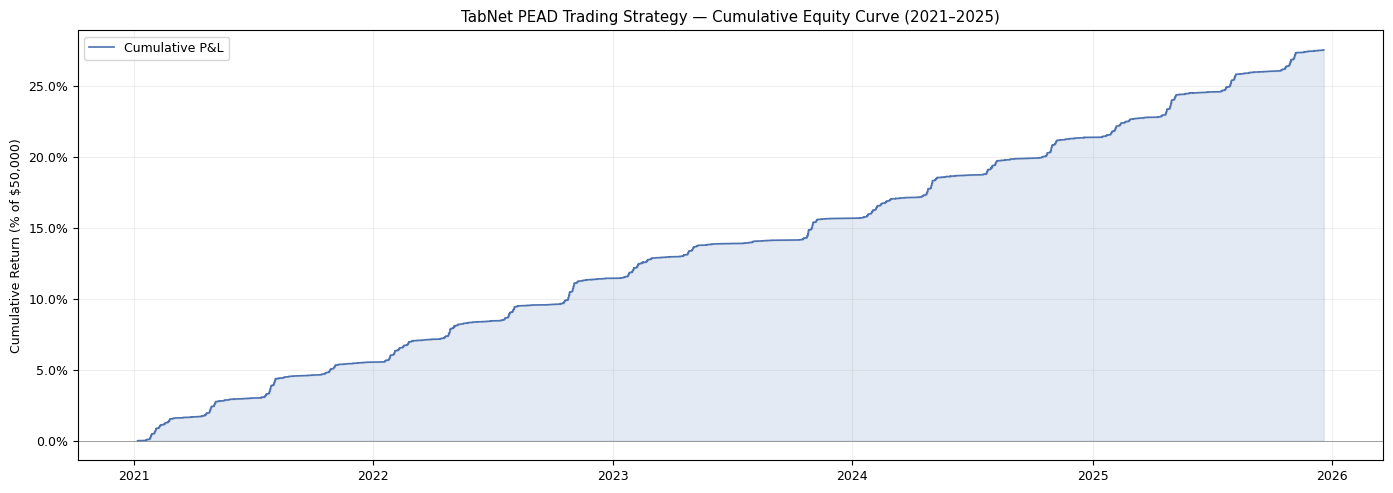


Total P&L: $13,791 (+27.6% on $50,000 capital)
Number of trades: 8221


In [22]:
# ── Build cumulative equity curve ────────────────────────────────────
pnl = signals["pnl_per_trade"].to_numpy()
cum_pnl = np.cumsum(pnl)

# Starting capital: enough to cover concurrent positions
# Each quarter has ~200-500 trades. Max concurrent positions ≈ 500
initial_capital = 50_000
cum_return_pct = (cum_pnl / initial_capital) * 100
dates = signals["earnings_date"].to_numpy()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dates, cum_return_pct, color="#4C72B0", linewidth=1.2, label="Cumulative P&L")
ax.fill_between(
    dates, 0, cum_return_pct,
    where=(np.array(cum_return_pct) >= 0),
    color="#4C72B0", alpha=0.15,
)
ax.fill_between(
    dates, 0, cum_return_pct,
    where=(np.array(cum_return_pct) < 0),
    color="#C44E52", alpha=0.15,
)
ax.axhline(0, color="gray", linewidth=0.5)
ax.set_ylabel(f"Cumulative Return (% of ${initial_capital:,})")
ax.set_title("TabNet PEAD Trading Strategy — Cumulative Equity Curve (2021–2025)")
ax.legend()
ax.grid(alpha=0.2)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
plt.tight_layout()
plt.show()

total_pnl = cum_pnl[-1]
total_return_pct = (total_pnl / initial_capital) * 100
print(f"\nTotal P&L: ${total_pnl:,.0f} ({total_return_pct:+.1f}% on ${initial_capital:,} capital)")
print(f"Number of trades: {len(signals)}")

---
## 3. Per-Quarter Breakdown

In [23]:
# ── Aggregate by quarter ─────────────────────────────────────────────
quarterly = signals.group_by("quarter").agg([
    pl.len().alias("trades"),
    pl.sum("pnl_per_trade").alias("total_pnl"),
    pl.mean("trade_return").alias("avg_return"),
    (pl.col("trade_return") > 0).mean().alias("win_rate"),
    pl.std("trade_return").alias("std_return"),
    # Hit 2% target (capped) vs exited at t10 close
    (pl.col("target_return_actual") > 0.02).sum().alias("hit_2pct"),
    (pl.col("target_return_actual") <= 0.02).sum().alias("exit_t10"),
    # What was the true class for these buy signals?
    (pl.col("target_class_actual") == 0).sum().alias("true_low"),
    (pl.col("target_class_actual") == 1).sum().alias("true_mod"),
    (pl.col("target_class_actual") == 2).sum().alias("true_strong"),
])

# Sort chronologically
quarterly = quarterly.with_columns([
    pl.col("quarter").str.split("_").list.get(0).cast(pl.Int32).alias("year"),
    pl.col("quarter").str.split("_").list.get(1).str.replace("Q", "").cast(pl.Int32).alias("qnum"),
])
quarterly = quarterly.sort(["year", "qnum"]).drop(["year", "qnum"])

# Pretty print
print(f"{'Qtr':<9} {'Trds':>5} {'P&L':>9} {'Avg R':>7} {'Win%':>6}"
      f" {'Hit 2%':>7} {'@t10':>5} {'TrLow':>6} {'TrMod':>6} {'TrStr':>6}")
print(f"{'-'*82}")
for row in quarterly.iter_rows():
    q, n, pnl_val, avg, wr, std, hit, t10, lo, mo, hi = row
    print(f"{q:<9} {n:>5} {pnl_val:>+9,.0f} {avg:>7.2%} {wr:>6.1%}"
          f" {hit:>7} {t10:>5} {lo:>6} {mo:>6} {hi:>6}")

print(f"\nColumn guide:")
print(f"  Hit 2%  = trades capped at 2% (stock hit target)")
print(f"  @t10    = trades exited at t+10 close (never hit 2%)")
print(f"  TrLow   = true class was Low  (model bought anyway — wrong!)")
print(f"  TrMod   = true class was Moderate (model was right)")
print(f"  TrStr   = true class was Strong   (model was right)")
print(f"\nAvg Ret explained:")
print(f"  Each trade returns either 2% (if stock hit 2% target)")
print(f"  or the actual t+10 return (if it never hit 2%).")
print(f"  Since ~90%+ trades hit 2%, the avg is near 2%, pulled")
print(f"  down by the ~5-10% of 'exit at t10' trades that are")
print(f"  slightly negative. Avg ≈ 2% × hit_rate + avg_loss × (1-hit_rate).")

print(f"\nBest quarter:  {quarterly.top_k(1, by='total_pnl')['quarter'][0]}  "
      f"(${quarterly['total_pnl'].max():,.0f})")
print(f"Worst quarter: {quarterly.bottom_k(1, by='total_pnl')['quarter'][0]}  "
      f"(${quarterly['total_pnl'].min():,.0f})")

Qtr        Trds       P&L   Avg R   Win%  Hit 2%  @t10  TrLow  TrMod  TrStr
----------------------------------------------------------------------------------
2021_Q1     488      +842   1.73%  97.7%     373   115    115     89    284
2021_Q2     387      +665   1.72%  96.1%     281   106    106    112    169
2021_Q3     489      +811   1.66%  97.3%     318   171    171    139    179
2021_Q4     263      +454   1.73%  98.1%     195    68     68     80    115
2022_Q1     491      +808   1.65%  94.7%     344   147    147    108    236
2022_Q2     487      +650   1.33%  85.2%     282   205    205    116    166
2022_Q3     323      +580   1.80%  96.6%     270    53     53     63    207
2022_Q4     492      +921   1.87%  98.0%     436    56     56     93    343
2023_Q1     491      +760   1.55%  93.7%     304   187    187    143    161
2023_Q2     298      +468   1.57%  94.6%     190   108    108     91     99
2023_Q3      73      +119   1.62%  97.3%      46    27     27     17     29
2023_

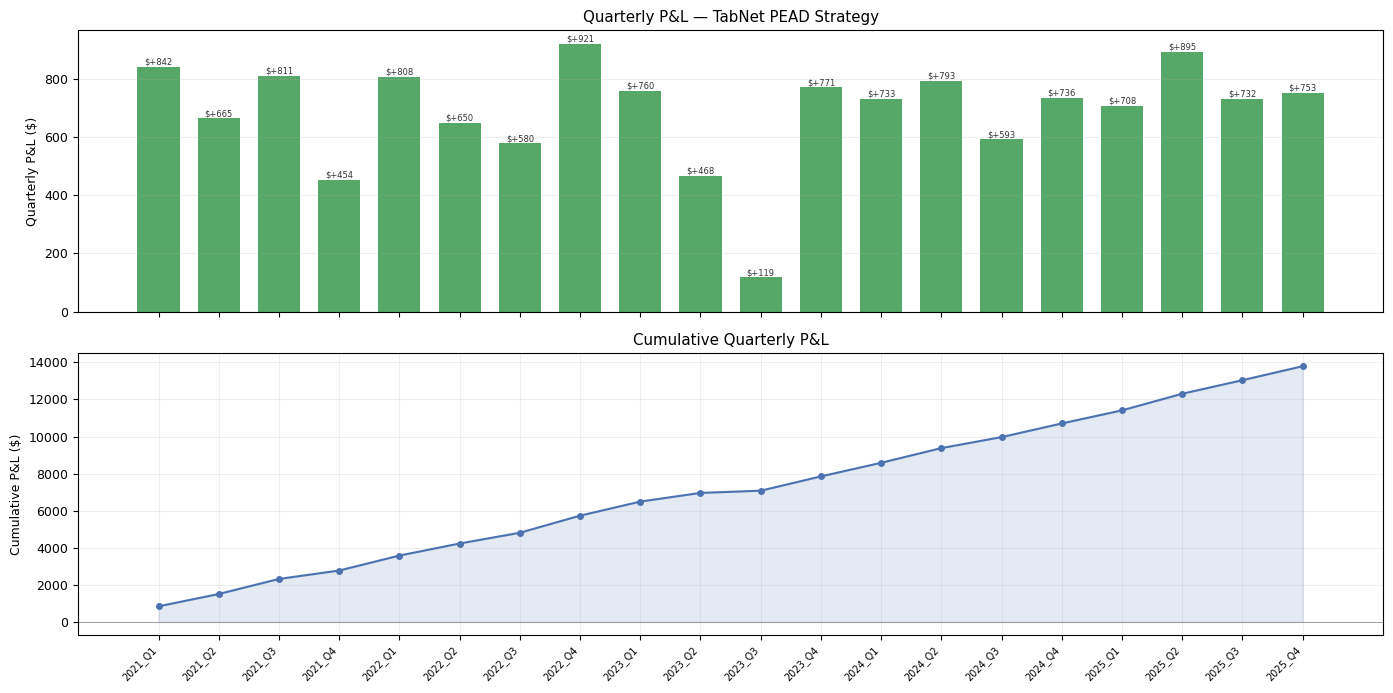

In [24]:
# ── Quarterly P&L bars ───────────────────────────────────────────────
q_labels = quarterly["quarter"].to_list()
q_pnl = quarterly["total_pnl"].to_numpy()
q_cum = np.cumsum(q_pnl)
q_win = quarterly["win_rate"].to_numpy()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# ── Per-quarter P&L bars ─────────────────────────────────────────────
ax = axes[0]
colors = ["#55A868" if v > 0 else "#C44E52" for v in q_pnl]
ax.bar(range(len(q_labels)), q_pnl, color=colors, width=0.7)
ax.axhline(0, color="gray", lw=0.5)
ax.set_ylabel("Quarterly P&L ($)")
ax.set_title("Quarterly P&L — TabNet PEAD Strategy")
ax.grid(alpha=0.2, axis="y")
for i, v in enumerate(q_pnl):
    va = "bottom" if v >= 0 else "top"
    ax.text(i, v, f"${v:+,.0f}", ha="center", va=va, fontsize=6,
            color="#333333")

# ── Cumulative P&L ────────────────────────────────────────────────────
ax = axes[1]
x = np.arange(len(q_labels))
ax.plot(x, q_cum, marker="o", markersize=4, color="#4C72B0", lw=1.5)
ax.fill_between(x, 0, q_cum, alpha=0.15, color="#4C72B0")
ax.axhline(0, color="gray", lw=0.5)
ax.set_xticks(x)
ax.set_xticklabels(q_labels, rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Cumulative P&L ($)")
ax.set_title("Cumulative Quarterly P&L")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

---
## 4. Sharpe Ratio & Risk Metrics

In [25]:
returns = signals["trade_return"].to_numpy()
n_trades = len(returns)

# ── Sharpe ratio (annualised) ────────────────────────────────────────
# Assuming trades are per-daily earnings dates. Annualisation factor:
# Each trade is a discrete event spaced across ~250 trading days/year.
# We annualise: Sharpe = mean_return / std_return * sqrt(trades_per_year)
days_span = (signals["earnings_date"].max() - signals["earnings_date"].min()).days
years = days_span / 365.25
trades_per_year = n_trades / years if years > 0 else n_trades

mean_ret = returns.mean()
std_ret = returns.std()
sharpe = (mean_ret / std_ret) * np.sqrt(trades_per_year) if std_ret > 0 else 0

# ── Max drawdown ─────────────────────────────────────────────────────
equity_curve = (1 + returns).cumprod()
running_max = np.maximum.accumulate(equity_curve)
drawdowns = (equity_curve - running_max) / running_max
max_drawdown = drawdowns.min()

# ── Trade-by-trade drawdown ──────────────────────────────────────────
pnl_cum = np.cumsum(pnl)
pnl_peak = np.maximum.accumulate(pnl_cum)
pnl_dd = pnl_cum - pnl_peak
max_pnl_dd = pnl_dd.min()

print(f"{'='*50}")
print(f"{'RISK METRICS':^50}")
print(f"{'='*50}")
print(f"  Total trades:          {n_trades:>8,}")
print(f"  Timespan:              {years:>8.1f} years")
print(f"  Trades per year:       {trades_per_year:>8.0f}")
print(f"  Mean return:           {mean_ret:>8.2%}")
print(f"  Std return:            {std_ret:>8.2%}")
print(f"  Sharpe ratio (ann.):   {sharpe:>8.2f}")
print(f"  Win rate:              {(returns > 0).mean():>8.1%}")
print(f"  Max P&L drawdown:     ${max_pnl_dd:>8,.0f}")
print(f"  Max % drawdown:       {max_drawdown:>8.2%}")
print(f"  Total P&L:            ${sum(pnl):>8,.0f}")

                   RISK METRICS                   
  Total trades:             8,221
  Timespan:                   4.9 years
  Trades per year:           1662
  Mean return:              1.68%
  Std return:               0.71%
  Sharpe ratio (ann.):      95.68
  Win rate:                 95.7%
  Max P&L drawdown:     $     -13
  Max % drawdown:        -13.15%
  Total P&L:            $  13,791


---
## 5. Drawdown Chart

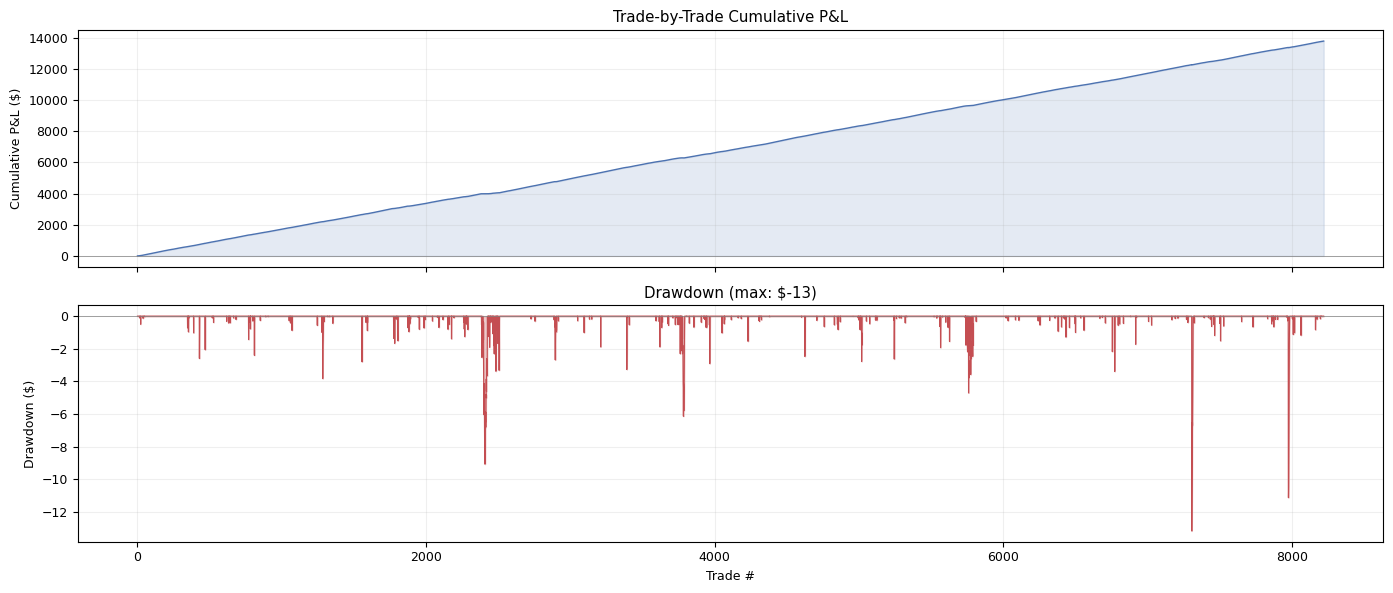

In [26]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# ── Cumulative P&L (trade-by-trade) ───────────────────────────────────
trade_idx = np.arange(len(pnl_cum))
ax1.plot(trade_idx, pnl_cum, color="#4C72B0", lw=1)
ax1.fill_between(trade_idx, 0, pnl_cum, alpha=0.15, color="#4C72B0")
ax1.set_ylabel("Cumulative P&L ($)")
ax1.set_title("Trade-by-Trade Cumulative P&L")
ax1.grid(alpha=0.2)
ax1.axhline(0, color="gray", lw=0.5)

# ── Drawdown ──────────────────────────────────────────────────────────
ax2.fill_between(trade_idx, 0, pnl_dd, color="#C44E52", alpha=0.3)
ax2.plot(trade_idx, pnl_dd, color="#C44E52", lw=0.8)
ax2.set_ylabel("Drawdown ($)")
ax2.set_xlabel("Trade #")
ax2.set_title(f"Drawdown (max: ${max_pnl_dd:,.0f})")
ax2.grid(alpha=0.2)
ax2.axhline(0, color="gray", lw=0.5)

plt.tight_layout()
plt.show()

---
## 6. Strategy Breakdown by Predicted Class


Class 1 (Moderate):
  Trades:             2290
  Mean return:         1.66%
  Median return:       2.00%
  Win rate:            96.3%
  Sharpe (ann.):       55.93
  Total P&L:       $   3,793

Class 2 (Strong):
  Trades:             5931
  Mean return:         1.69%
  Median return:       2.00%
  Win rate:            95.5%
  Sharpe (ann.):       78.63
  Total P&L:       $   9,998


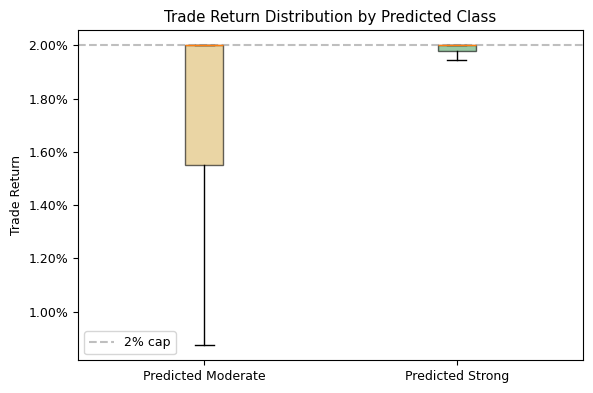

In [27]:
for cls in [1, 2]:
    sub = signals.filter(pl.col("target_class_predicted") == cls)
    sub_rets = sub["trade_return"].to_numpy()
    wr = (sub_rets > 0).mean()
    sr = (sub_rets.mean() / sub_rets.std()) * np.sqrt(len(sub_rets) / years) if sub_rets.std() > 0 else 0
    print(f"\nClass {cls} ({'Moderate' if cls == 1 else 'Strong'}):")
    print(f"  Trades:           {len(sub):>6}")
    print(f"  Mean return:      {sub_rets.mean():>8.2%}")
    print(f"  Median return:    {np.median(sub_rets):>8.2%}")
    print(f"  Win rate:         {wr:>8.1%}")
    print(f"  Sharpe (ann.):    {sr:>8.2f}")
    print(f"  Total P&L:       ${sub['pnl_per_trade'].sum():>8,.0f}")

# ── Compare classes visually ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
bp = ax.boxplot(
    [signals.filter(pl.col("target_class_predicted") == c)["trade_return"].to_numpy()
     for c in [1, 2]],
    tick_labels=["Predicted Moderate", "Predicted Strong"],
    showfliers=False,
    patch_artist=True,
)
for patch, color in zip(bp["boxes"], ["#DDB967", "#55A868"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.axhline(0.02, color="gray", ls="--", alpha=0.5, label="2% cap")
ax.set_ylabel("Trade Return")
ax.set_title("Trade Return Distribution by Predicted Class")
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.show()

---
## 7. Yearly Summary

Year    Trades    P&L ($)   Avg Ret  Win Rate   Std Ret
------------------------------------------------------
2021      1627     +2,772     1.70%     97.3%    0.0063
2022      1793     +2,959     1.65%     93.4%    0.0076
2023      1289     +2,118     1.64%     95.4%    0.0070
2024      1675     +2,855     1.70%     96.2%    0.0067
2025      1837     +3,087     1.68%     96.4%    0.0078


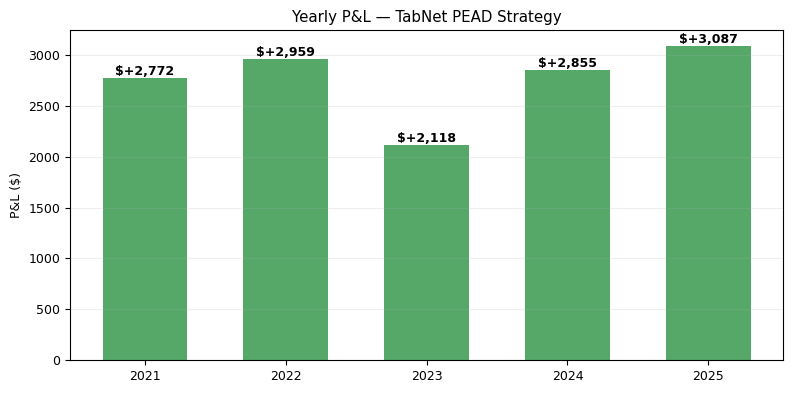

In [28]:
yearly = signals.with_columns(
    pl.col("earnings_date").dt.year().alias("year")
).group_by("year").agg([
    pl.len().alias("trades"),
    pl.sum("pnl_per_trade").alias("total_pnl"),
    pl.mean("trade_return").alias("avg_return"),
    (pl.col("trade_return") > 0).mean().alias("win_rate"),
    pl.std("trade_return").alias("std_return"),
]).sort("year")

print(f"{'Year':<6} {'Trades':>7} {'P&L ($)':>10} {'Avg Ret':>9} {'Win Rate':>9} {'Std Ret':>9}")
print(f"{'-'*54}")
for row in yearly.iter_rows():
    yr, n, pnl_val, avg, wr, std = row
    print(f"{yr:<6} {n:>7} {pnl_val:>+10,.0f} {avg:>9.2%} {wr:>9.1%} {std:>9.4f}")

# ── Yearly P&L bars ───────────────────────────────────────────────────
yearly_rows = yearly.to_dicts()
y_labels = [str(r["year"]) for r in yearly_rows]
y_pnl = [r["total_pnl"] for r in yearly_rows]

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#55A868" if v > 0 else "#C44E52" for v in y_pnl]
ax.bar(y_labels, y_pnl, color=colors, width=0.6)
ax.axhline(0, color="gray", lw=0.5)
ax.set_ylabel("P&L ($)")
ax.set_title("Yearly P&L — TabNet PEAD Strategy")
ax.grid(alpha=0.2, axis="y")
for lbl, v in zip(y_labels, y_pnl):
    va = "bottom" if v >= 0 else "top"
    ax.text(lbl, v, f"${v:+,.0f}", ha="center", va=va, fontsize=9,
            fontweight="bold")
plt.tight_layout()
plt.show()

---
## Notes

- **Exit price**: For trades where `target_return_actual > 2%`, the return is capped at 2% (assumes
  exit at exactly 2%, not at the peak). For trades ≤2%, the actual t+10 return is used.
- **Position sizing**: Fixed $1,000 per trade. No portfolio-level risk management (no correlation
  adjustment, no sector limits).
- **Slippage/commissions**: Not modeled. Add ~5-10 bps per trade for realistic backtesting.
- **Lookahead**: The `target_return_actual` is the *ex-post* realised return. Live trading would
  use the `target_return_predicted` from the regressor to set take-profit/target levels.
- **Enhancement**: For a more accurate backtest, include `max_high` in the results table to know
  *when* the 2% was hit, enabling exact exit price calculation.